## Experimental Scenario 1: IID Baseline (Uniform)

This scenario serves as the **baseline** for our federated learning study. The objective is to evaluate model performance under ideal distribution conditions before introducing heterogeneity or privacy constraints.

### Scenario Description
In this configuration, the **Diabetes** dataset is distributed in an **IID** (Independent and Identically Distributed) manner among participants.

* **Number of clients:** 10
* **Distribution:** Uniform (each client possesses a representative sample of the global population).
* **Class Proportions:** Approximately 86% Class `0` (Healthy) and 14% Class `1` (Diabetes) per client.
* **Aggregation Algorithm:** `FedAvg` (Federated Averaging).

### Evaluated Models
Three architectures of varying complexity are compared to identify the best trade-off between utility and cost:

| Model | Type | Description |
| :--- | :--- | :--- |
| **LR** | Linear | Logistic Regression (21 inputs, 2 outputs). A lightweight model used to establish the performance baseline. |
| **MLP** | Non-linear | Multi-Layer Perceptron. Capable of capturing complex relationships between health indicators. |
| **SVM** | Maximum Margin | Support Vector Machine. Evaluates the robustness of class separation in a federated setting. |



### Imports / Paths / Utils

In [5]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix

# Imports spécifiques Fluke
from fluke_package.fluke.data.datasets import Datasets
from fluke_package.fluke.nets import Diabetes_LR, Diabetes_SVM, Diabetes_MLP

# Configuration globale
BASE_PATH = Path('runs/IID')
MODELS = ['LR', 'MLP', 'SVM']
COLORS = {'LR': '#1f77b4', 'MLP': '#ff7f0e', 'SVM': '#2ca02c'}
LEGEND = {'LR': 'Logistic Regression', 'MLP': 'Multi-Layer Perceptron', 'SVM': 'SVM'}

# Chemins spécifiques vers les dossiers de hash
PATHS = {
    'LR':  BASE_PATH / 'LR'  / 'model',
    'MLP': BASE_PATH / 'MLP' / 'model',
    'SVM': BASE_PATH / 'SVM' / 'model',
}

data_container = Datasets.DIABETES()


def load_global_metrics(run_path: Path) -> pd.DataFrame:
    global_csv = run_path / 'global_metrics.csv'
    metrics_csv = run_path / 'metrics.csv'
    if global_csv.exists():
        return pd.read_csv(global_csv)
    if metrics_csv.exists():
        return pd.read_csv(metrics_csv)
    raise FileNotFoundError(f'No global metrics CSV in {run_path}')


def load_comm_costs(run_path: Path):
    path = run_path / 'comm_costs.csv'
    return pd.read_csv(path) if path.exists() else None


def load_run_time(run_path: Path):
    path = run_path / 'run_metrics.csv'
    if not path.exists():
        return None
    df = pd.read_csv(path)
    row = df[df['metric'] == 'run_time_seconds']
    if row.empty:
        return None
    return float(row['value'].iloc[0])


cwd = Path.cwd()
print(f"Current working directory: {cwd}")
base = cwd / 'runs'
print(f"Looking for runs in: {base}")


Distribution of target (Diabetes_binary) :
   - No Diabetes ((0,)): 218334 persons (86.07%)
   - No Diabetes ((1,)): 35346 persons (13.93%)
--------------------------------------------------
Sensible variable 'Sex' detected at index : 17

Size of the dataset :
   - Train set : 202944 samples, 21 features
   - Test set  : 50736 samples
--------------------------------------------------
Current working directory: c:\Users\bapti\Documents\INSA\S2\Cours\FL\M1_Federated_learning\project_medical_fl_implementation
Looking for runs in: c:\Users\bapti\Documents\INSA\S2\Cours\FL\M1_Federated_learning\project_medical_fl_implementation\runs


### Utility metrics

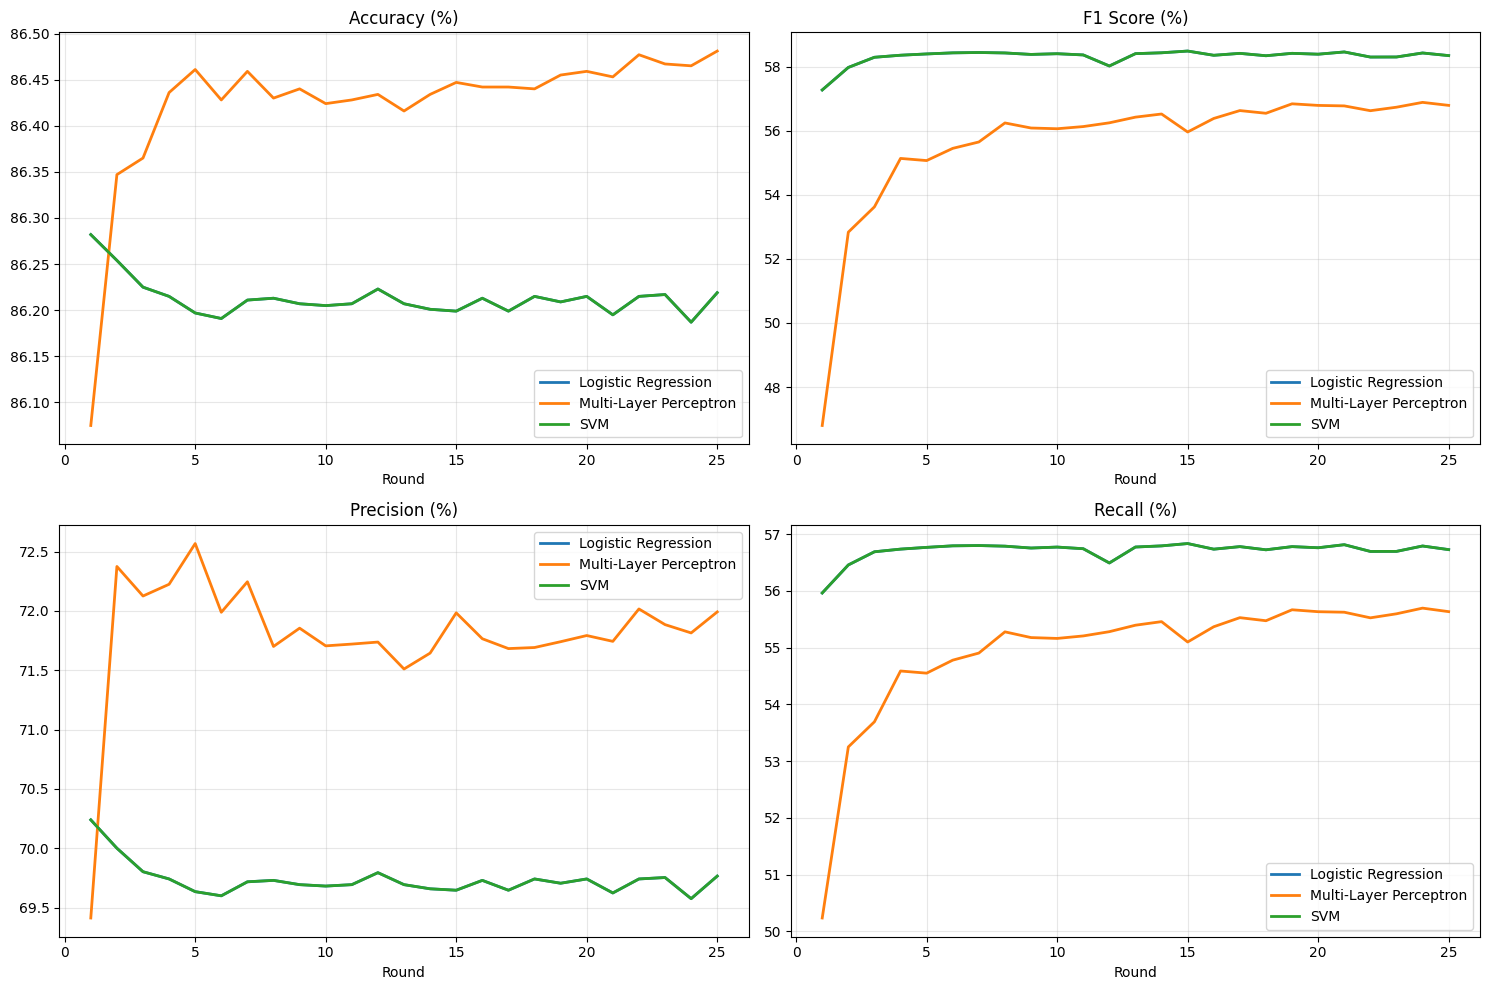

In [6]:
def plot_utility_metrics(paths_dict):
    metrics = {name: load_global_metrics(p.parent) for name, p in paths_dict.items()}
    
    plots = [
        ('accuracy', 'Accuracy (%)'),
        ('macro_f1', 'F1 Score (%)'),
        ('macro_precision', 'Precision (%)'),
        ('macro_recall', 'Recall (%)')
    ]

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()

    for i, (col, title) in enumerate(plots):
        for name, df in metrics.items():
            if df.empty: continue
            actual_col = col if col in df.columns else f'test_{col}'
            
            if actual_col in df.columns:
                axes[i].plot(df['round'], df[actual_col] * 100, 
                             label=LEGEND[name], color=COLORS[name], lw=2)
        
        axes[i].set_title(title)
        axes[i].set_xlabel('Round')
        axes[i].grid(True, alpha=0.3)
        axes[i].legend()

    plt.tight_layout()
    plt.show()

plot_utility_metrics(PATHS)

### Confusion matrix

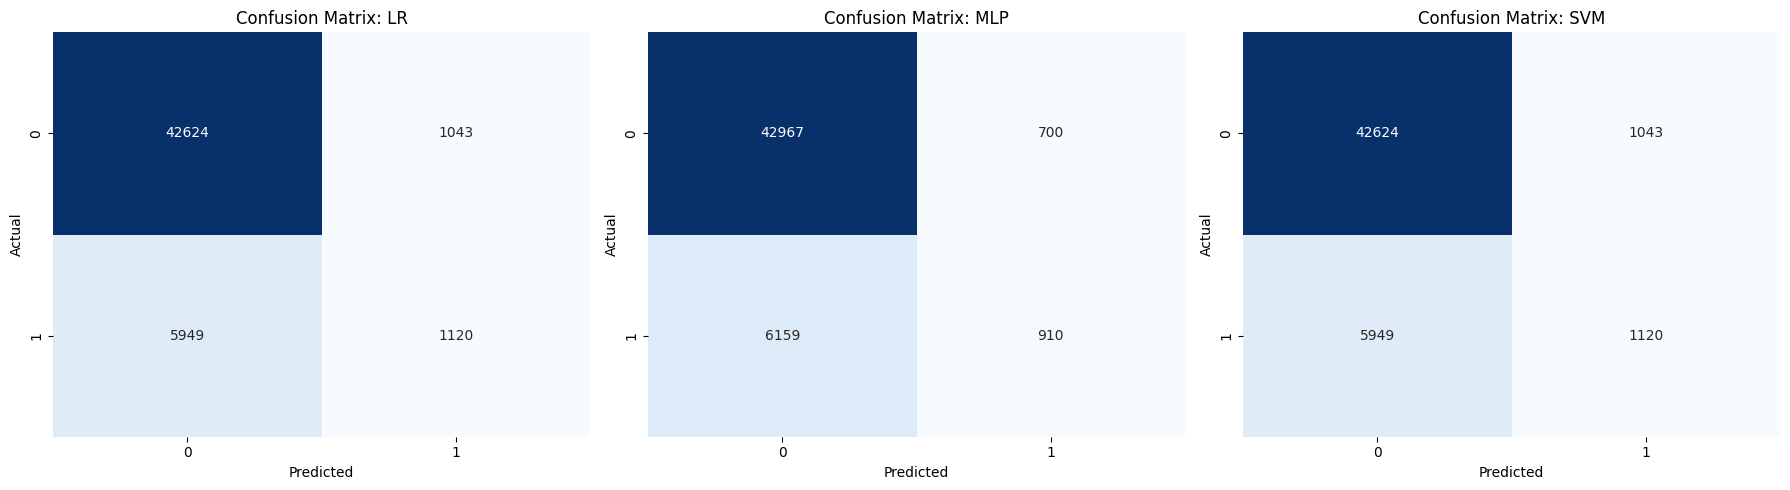

In [7]:
def get_model_instance(name):
    classes = {'LR': Diabetes_LR, 'MLP': Diabetes_MLP, 'SVM': Diabetes_SVM}
    return classes[name](input_dim=21)

def plot_all_confusion_matrices(paths_dict, data):
    X_test, y_test = data.test
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for i, (name, path) in enumerate(paths_dict.items()):
        model = get_model_instance(name)
        model.load_state_dict(torch.load(path / 'final_model.pth', map_location='cpu'))
        model.eval()
        
        with torch.no_grad():
            preds = torch.argmax(model(X_test), dim=1)
        
        cm = confusion_matrix(y_test, preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
        axes[i].set_title(f'Confusion Matrix: {name}')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')
        
    plt.tight_layout()
    plt.show()

plot_all_confusion_matrices(PATHS, data_container)

### Cost metrics

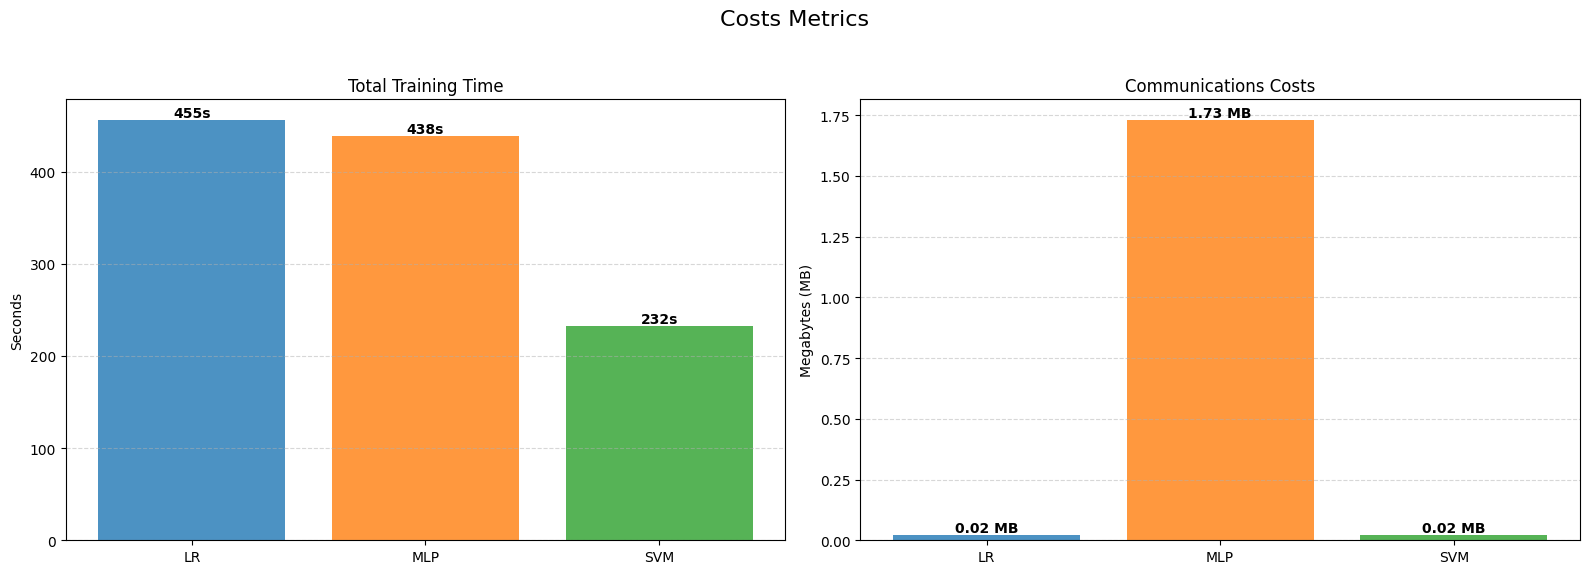

In [11]:
def plot_costs(base_path, model_list):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Costs Metrics', fontsize=16)
    
    times = {m: load_run_time(base_path / m) for m in model_list}

    active_times = {k: v for k, v in times.items() if v is not None}
    
    bars_t = ax1.bar(active_times.keys(), active_times.values(), 
                     color=[COLORS[m] for m in active_times.keys()], alpha=0.8)
    ax1.set_title('Total Training Time')
    ax1.set_ylabel('Seconds')
    ax1.grid(axis='y', linestyle='--', alpha=0.5)

    for bar in bars_t:
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                 f'{int(bar.get_height())}s', ha='center', va='bottom', fontweight='bold')

    comm_totals = {}
    for m in model_list:
        df_comm = load_comm_costs(base_path / m)
        if df_comm is not None and 'comm_costs' in df_comm.columns:
            # On calcule le total cumulé à la fin du dernier round et conversion en MB
            total_mb = df_comm['comm_costs'].sum() / (1024**2)
            comm_totals[m] = total_mb

    bars_c = ax2.bar(comm_totals.keys(), comm_totals.values(), 
                     color=[COLORS[m] for m in comm_totals.keys()], alpha=0.8)
    ax2.set_title('Communications Costs')
    ax2.set_ylabel('Megabytes (MB)')
    ax2.grid(axis='y', linestyle='--', alpha=0.5)

    # Ajout des labels sur les barres
    for bar in bars_c:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.2f} MB', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Utilisation
plot_costs(BASE_PATH, MODELS)

### Fairness metrics

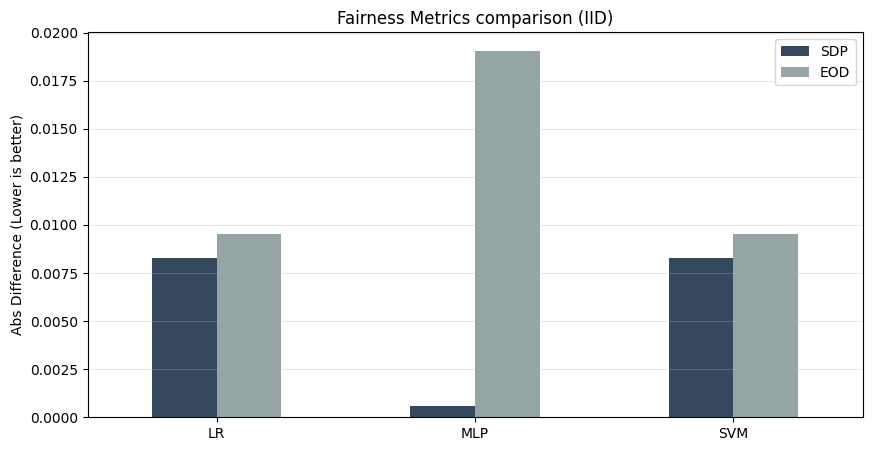

In [12]:
def compute_fairness_for_all(paths, data_container, sex_index=17):
    X_test, y_test = data_container.test
    results = {}
    
    model_classes = {'LR': Diabetes_LR, 'MLP': Diabetes_MLP, 'SVM': Diabetes_SVM}
    
    # Masques de groupes (Sex: 1 vs 0)
    g1_mask = (X_test[:, sex_index] > 0)
    g0_mask = (X_test[:, sex_index] <= 0)
    mask_y1 = (y_test == 1)

    def get_rate(predictions, mask):
        return predictions[mask].float().mean().item() if mask.any() else 0.0

    for name, path in paths.items():
        model_file = path / 'final_model.pth'
        if not model_file.exists() or name not in model_classes:
            continue

        # Chargement du modèle
        model = model_classes[name](input_dim=21)
        model.load_state_dict(torch.load(model_file, map_location='cpu'))
        model.eval()

        with torch.no_grad():
            preds = torch.argmax(model(X_test), dim=1)

        # Calcul SDP : |P(pred=1|G=1) - P(pred=1|G=0)|
        sdp = abs(get_rate(preds, g1_mask) - get_rate(preds, g0_mask))

        # Calcul EOD : |P(pred=1|G=1, y=1) - P(pred=1|G=0, y=1)|
        eod = abs(get_rate(preds, g1_mask & mask_y1) - get_rate(preds, g0_mask & mask_y1))

        results[name] = {'SDP': sdp, 'EOD': eod}
    
    return results


def plot_fairness(paths_dict, data):
    results = compute_fairness_for_all(paths_dict, data) 
    df_fair = pd.DataFrame(results).T
    
    df_fair.plot(kind='bar', figsize=(10, 5), color=['#34495e', '#95a5a6'])
    plt.title('Fairness Metrics comparison (IID)')
    plt.ylabel('Abs Difference (Lower is better)')
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

plot_fairness(PATHS, data_container)